<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Decision Making with Business Statistics</center></font>
<center><font size=5>Week 4: Project: E-News Express</font></center>

## Define Problem Statement and Objectives

E-news Express aims to increase its subscriber base but has observed a possible decline in new monthly subscriptions, potentially due to an underperforming landing page. To address this, E-News developed and tested a new landing page against the existing version using an A/B experiment. The objective of this analysis is to evaluate whether the new landing page improves user engagement and conversion rates. Additionally, the study examines whether user behavior varies based on language preference. Using statistical analysis at a 5% significance level, we aim to determine if the new design leads to measurable improvements. The results will inform data-driven decisions on whether to implement the new page and guide future optimization efforts.

*Questions Addressed*
1. Do the users spend more time on the new landing page than the existing landing page?

2. Is the conversion rate for the new page greater than the conversion rate for the old page?

3. Are conversion rate and preferred language independent or related?

4. Is the time spent on the new page the same for the different language users?

## Import all the necessary libraries

In [1]:
# Note: The following libraries are required. Install if needed before running.
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scipy==1.11.4 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
#Import Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import scipy.stats as stats

## Reading the Data into a DataFrame

In [3]:
#Create DataFrame
abtest_data = pd.read_csv('abtest.csv')

#Create a Copy DF to manipulate
df = abtest_data.copy()

## Explore the dataset and extract insights using Exploratory Data Analysis

- Data Overview
  - Viewing the first and last few rows of the dataset
  - Checking the shape of the dataset
  - Getting the statistical summary for the variables
- Check for missing values
- Check for duplicates

In [4]:
#View first 5 rows
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [5]:
#Viewing last 5 rows
df.tail()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


In [6]:
#Checking shape to get number of rows and columns (can also be determined from indexes of above views)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 100, Columns: 6


In [7]:
#View column names, non-null counts, data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [8]:
#Statistical Summary
df.describe(include='all')

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
count,100.000000,100,100,100.000000,100,100
unique,NaN,2,2,NaN,2,3
top,NaN,control,old,NaN,yes,Spanish
freq,NaN,50,50,NaN,54,34
mean,546517.000000,NaN,NaN,5.377800,NaN,NaN
std,52.295779,NaN,NaN,2.378166,NaN,NaN
min,546443.000000,NaN,NaN,0.190000,NaN,NaN
25%,546467.750000,NaN,NaN,3.880000,NaN,NaN
50%,546492.500000,NaN,NaN,5.415000,NaN,NaN
75%,546567.250000,NaN,NaN,7.022500,NaN,NaN


In [9]:
#Check for null values
df.isnull().sum()

user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64

In [10]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
#Check Unique users matches row count- every user has a unique ID
df['user_id'].nunique()

100

In [12]:
#Check that all control are on old page and all treatment group are on new
pd.crosstab(df['group'], df['landing_page'])

landing_page,new,old
group,,
control,0,50
treatment,50,0


We see there are 6 columns and 100 rows

There are no null values

There are no duplicates

There are 4 categorical object type variable columns

Time spent on both landing pages for the combined data ranged from .19 to 10.71 with a mean of 5.38 and std of 2.38

The crosstab confirms that the control group were exclusively shown the old landing page and treatment group shown the new, validating the A/B setup.

### Univariate Analysis

**Starting with the Categorical Columns**

group
control      50
treatment    50
Name: count, dtype: int64

Proportions:
 group
control      0.5
treatment    0.5
Name: proportion, dtype: float64


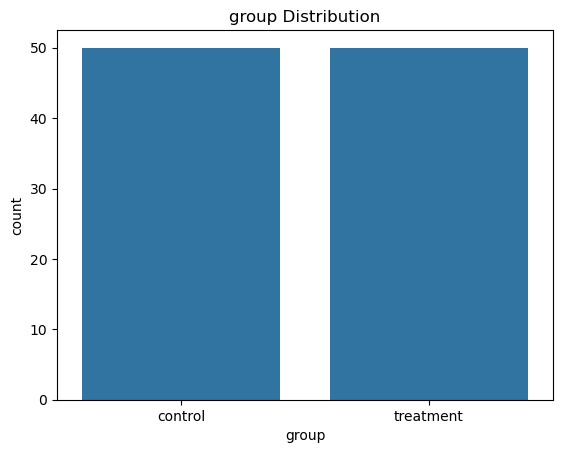

landing_page
old    50
new    50
Name: count, dtype: int64

Proportions:
 landing_page
old    0.5
new    0.5
Name: proportion, dtype: float64


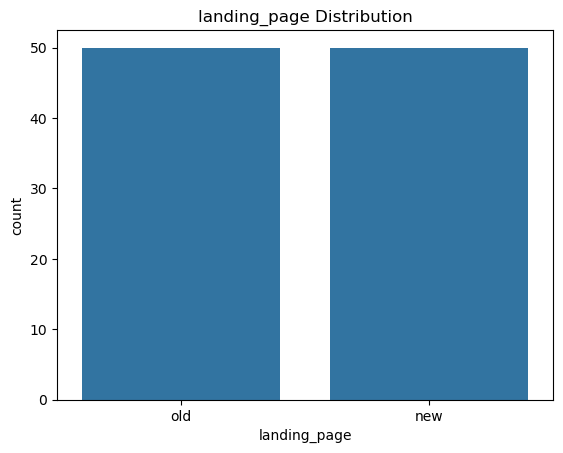

converted
yes    54
no     46
Name: count, dtype: int64

Proportions:
 converted
yes    0.54
no     0.46
Name: proportion, dtype: float64


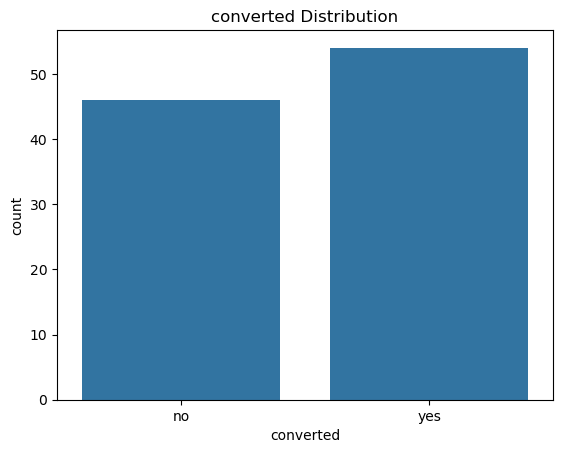

language_preferred
Spanish    34
French     34
English    32
Name: count, dtype: int64

Proportions:
 language_preferred
Spanish    0.34
French     0.34
English    0.32
Name: proportion, dtype: float64


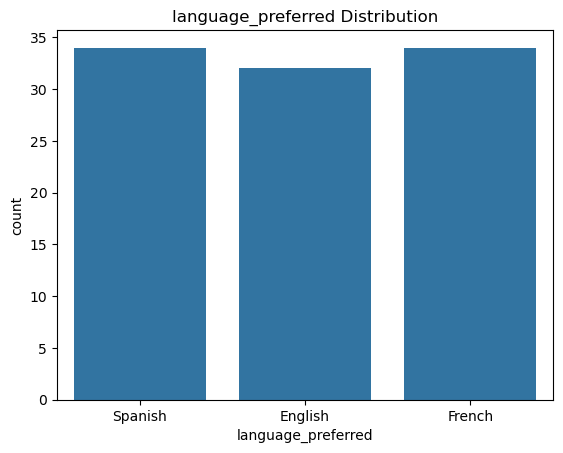

In [13]:
#Summarizing Categorical Data with value counts, normalized proportions, and count plots for each.
def categorical_summary(col):
  print(df[col].value_counts())
  print("\nProportions:\n", df[col].value_counts(normalize=True))
  sns.countplot(x=col, data=df)
  plt.title(f'{col} Distribution')
  plt.show()

categorical_summary('group')
categorical_summary('landing_page')
categorical_summary('converted')
categorical_summary('language_preferred')

As expected and demonstrated above in the crosstab, "landing_page" counts match "group" counts, validating the A/B setup.

The data set is evenly split between control and treatment groups (50 users each) ensuring balanced sampling.

There is an overall conversion rate of 54%, indicating that slightly more than half of all users subscribed.  This provides a useful baseline for comparing new and old conversion.

The page was viewed with 3 different language prefferences:

Spanish - 34%

French - 34%

English - 32%

The balance in preferences indicates that no single language dominates and allows for balanced sampling and fair comparison accross the 3 languages.

**Next looking at overall time spent on both landing pages**

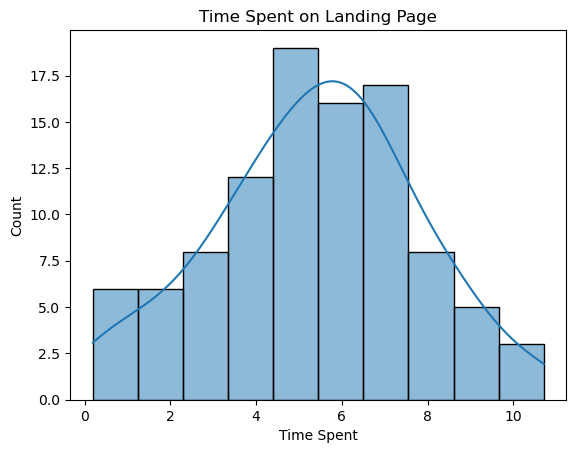

In [14]:
#Histplot of time spent on both pages
sns.histplot(x='time_spent_on_the_page', data=df, kde=True, bins=10)
plt.title('Time Spent on Landing Page')
plt.xlabel('Time Spent')
plt.ylabel('Count')
plt.show()

In [15]:
#Describing the histplot
df['time_spent_on_the_page'].describe()

count    100.000000
mean       5.377800
std        2.378166
min        0.190000
25%        3.880000
50%        5.415000
75%        7.022500
max       10.710000
Name: time_spent_on_the_page, dtype: float64

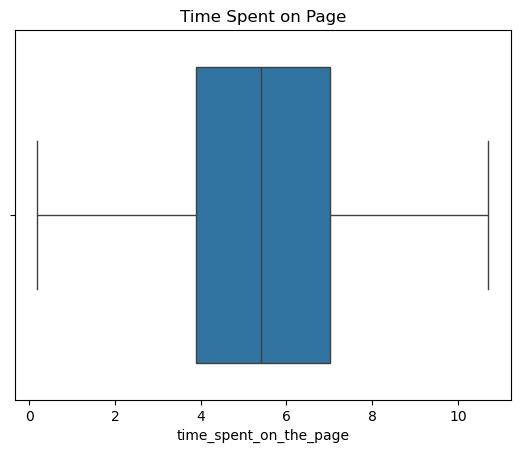

In [16]:
#Boxplot to visualize any outliers or skew
sns.boxplot(x=df['time_spent_on_the_page'])
plt.title('Time Spent on Page')
plt.show()

This data appears to follow a normal distribution, but let's investigate further.

In [17]:
#Shapiro-Wilk Test
from scipy.stats import shapiro

stat, p_value = shapiro(df['time_spent_on_the_page'])
print(f"Shapiro-Wilk p-value: {p_value:.4f}")

if p_value > 0.05:
    print("The data is consistent with normality.")
else:
    print("The data is not consistent with normality.")

Shapiro-Wilk p-value: 0.5643
The data is consistent with normality.


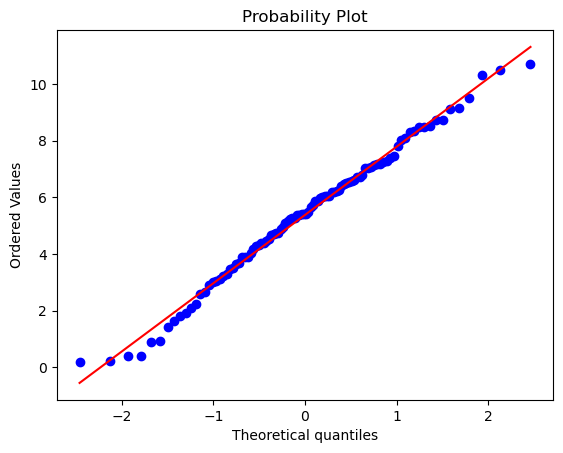

In [18]:
#Another method of visualizing normality
stats.probplot(df['time_spent_on_the_page'], dist="norm", plot=plt)
plt.show()

Based on the appearance of the histogram and probability plot, and the results of the Shapiro-Wilk test, the data appears approximately normal and parametric tests can be appropriately applied.

### Bivariate Analysis

**Time Spent New v. Old**

In [19]:
#Compare summary of time spent on new vs. old landing page
df.groupby('landing_page')['time_spent_on_the_page'].describe()

,count,mean,std,min,25%,50%,75%,max
landing_page,,,,,,,,
new,50.0,6.2232,1.817031,1.65,5.175,6.105,7.1600,10.71
old,50.0,4.5324,2.581975,0.19,2.720,4.380,6.4425,10.30


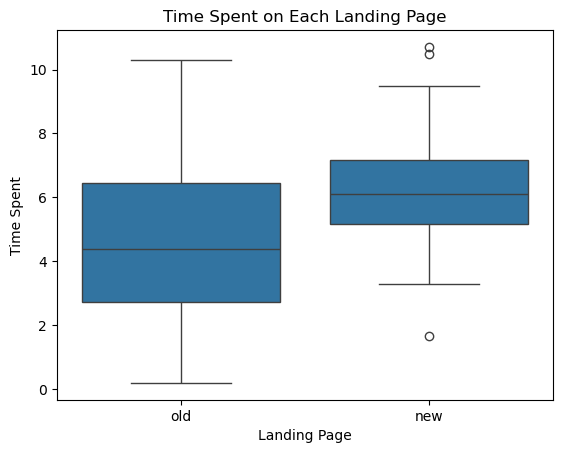

In [20]:
#Visualize in Boxplot form
sns.boxplot(x='landing_page', y='time_spent_on_the_page', data=df)
plt.title('Time Spent on Each Landing Page')
plt.xlabel('Landing Page')
plt.ylabel('Time Spent')
plt.show()

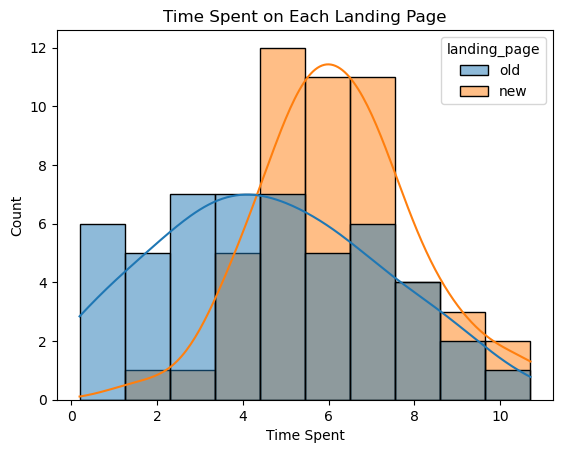

In [21]:
#Visualize in histplot form
sns.histplot(x='time_spent_on_the_page', hue='landing_page', data=df, kde=True, bins=10)
plt.title('Time Spent on Each Landing Page')
plt.xlabel('Time Spent')
plt.ylabel('Count')
plt.show()

The  new page data has some outliers in time spent on page, however these appear to represent legitimate customer behavior and therefore will be left in the data set untreated.

Both the old and new page sample data for time spent on the page appear approximately normal in distribution.

The new page shows a higher mean time spent.  A hypothesis test can be utilized to show whether this difference is statistically significant.

**Conversion New v. Old**

In [22]:
#Count of converted customers on new page vs. old
df.groupby('landing_page')['converted'].value_counts()

landing_page  converted
new           yes          33
              no           17
old           no           29
              yes          21
Name: count, dtype: int64

In [23]:
#Normalized new vs. old page conversions
df.groupby('landing_page')['converted'].value_counts(normalize=True)

landing_page  converted
new           yes          0.66
              no           0.34
old           no           0.58
              yes          0.42
Name: proportion, dtype: float64

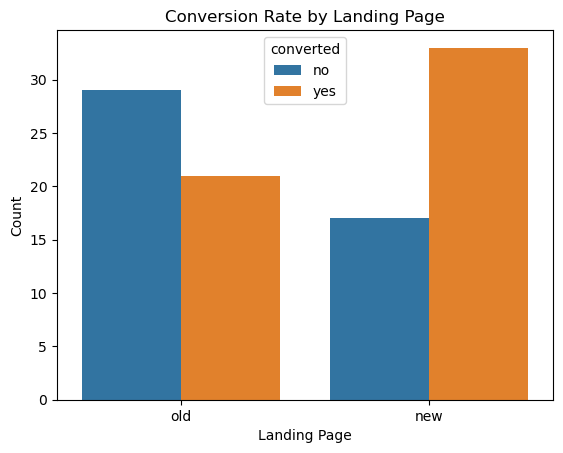

In [24]:
#Visualize with Count Plot
sns.countplot(x='landing_page', hue='converted', data=df)
plt.title('Conversion Rate by Landing Page')
plt.xlabel('Landing Page')
plt.ylabel('Count')
plt.show()

The conversion rate of the new page (66%) is substantially higher than the old page (42%) indicating significant improvement that should be validated through hypothesis testing.

**Relationship between Conversion and Time Spent on Landing Page**

In [25]:
#Comparing conversion with time spent on page
df.groupby('converted')['time_spent_on_the_page'].describe()

,count,mean,std,min,25%,50%,75%,max
converted,,,,,,,,
no,46.0,3.915870,2.226897,0.19,2.3375,3.980,4.9225,9.15
yes,54.0,6.623148,1.708427,2.58,5.5000,6.495,7.3675,10.71


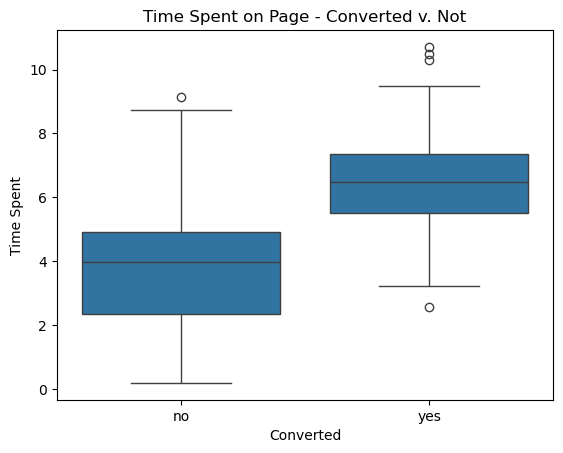

In [26]:
#Visualize in Boxplot form
sns.boxplot(x='converted', y='time_spent_on_the_page', data=df)
plt.title('Time Spent on Page - Converted v. Not')
plt.xlabel('Converted')
plt.ylabel('Time Spent')
plt.show()

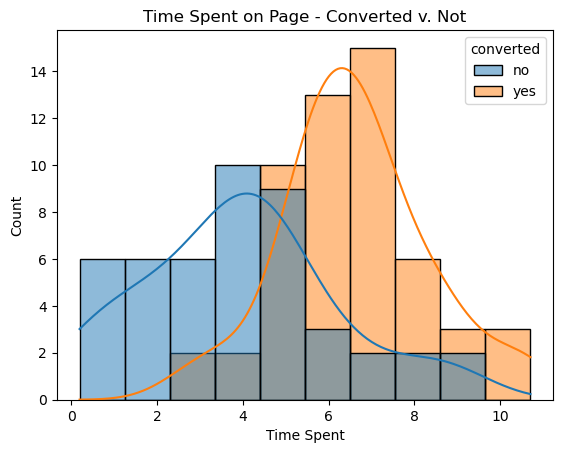

In [27]:
#Visualize in histplot form
sns.histplot(x='time_spent_on_the_page', hue='converted', data=df, kde=True, bins=10)
plt.title('Time Spent on Page - Converted v. Not')
plt.xlabel('Time Spent')
plt.ylabel('Count')
plt.show()

Again there are a few outliers, but these represent legitimate customer behavior and therefore will remain untreated.

Those converted during the study spent an average of 6.6 min on the landing page versus 3.9 min for those not converted.  This suggests a strong association between time spent on the landing page and conversion.

**Language Preference broken out by New and Old Page**

In [28]:
#Language preference viewed on new page v. old
df.groupby('landing_page')['language_preferred'].value_counts()

landing_page  language_preferred
new           French                17
              Spanish               17
              English               16
old           French                17
              Spanish               17
              English               16
Name: count, dtype: int64

In [29]:
df.groupby('landing_page')['language_preferred'].value_counts(normalize=True)

landing_page  language_preferred
new           French                0.34
              Spanish               0.34
              English               0.32
old           French                0.34
              Spanish               0.34
              English               0.32
Name: proportion, dtype: float64

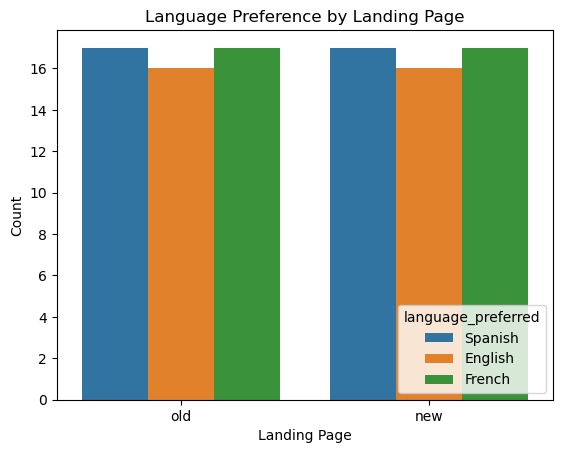

In [30]:
#Language preference by landing page visualized
ax = sns.countplot(data=df, x='landing_page', hue='language_preferred')
plt.title('Language Preference by Landing Page')
plt.xlabel('Landing Page')
plt.ylabel('Count')
sns.move_legend(ax, 'lower right')
plt.show()

Overall Language preference data is balanced with 34% Spanish, 34% French, and 32% English on both pages.

**Language Preference v. Time Spent on Landing Page**

In [31]:
#Language vs. time spent on landing page
df.groupby('language_preferred')['time_spent_on_the_page'].describe()

,count,mean,std,min,25%,50%,75%,max
language_preferred,,,,,,,,
English,32.0,5.559062,2.621079,0.22,3.6175,5.755,7.1375,10.50
French,34.0,5.253235,2.675413,0.40,3.3950,5.315,7.3675,10.71
Spanish,34.0,5.331765,1.818095,0.19,4.4750,5.605,6.5150,8.72


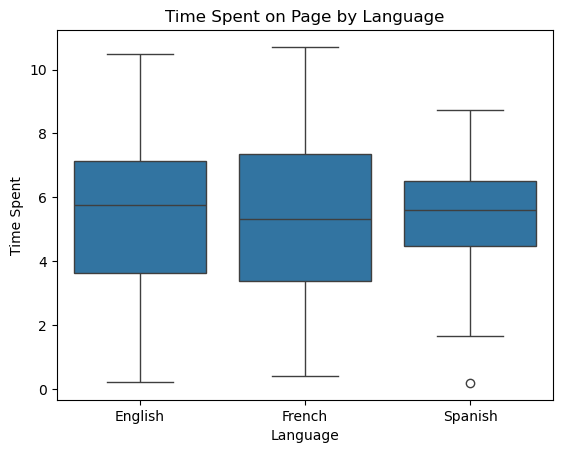

In [32]:
#Visualize in Boxplot form
sns.boxplot(x='language_preferred', y='time_spent_on_the_page', data=df, order=['English', 'French', 'Spanish'])
plt.title('Time Spent on Page by Language')
plt.xlabel('Language')
plt.ylabel('Time Spent')
plt.show()

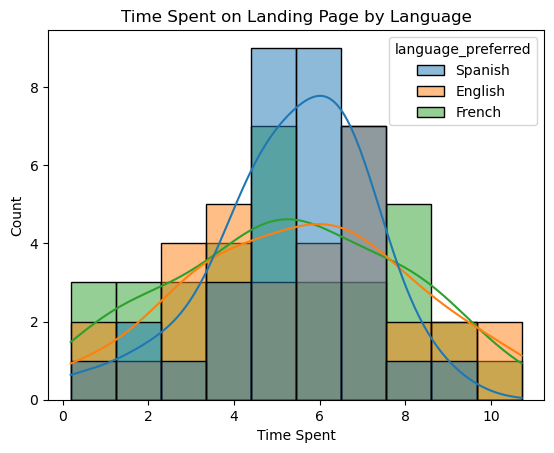

In [33]:
#Visualize in histplot form
sns.histplot(x='time_spent_on_the_page', hue='language_preferred', data=df, kde=True, bins=10)
plt.title('Time Spent on Landing Page by Language')
plt.xlabel('Time Spent')
plt.ylabel('Count')
plt.show()

**Time spent on New Landing Page by Language Preference**

In [34]:
#Time spent on the new landing page by language
df[df['landing_page']=='new'].groupby('language_preferred')['time_spent_on_the_page'].describe()

,count,mean,std,min,25%,50%,75%,max
language_preferred,,,,,,,,
English,16.0,6.663750,1.984150,3.65,5.3275,6.865,7.7125,10.50
French,17.0,6.196471,1.933394,3.30,5.2500,5.420,7.2700,10.71
Spanish,17.0,5.835294,1.525656,1.65,5.1500,6.200,6.7000,8.08


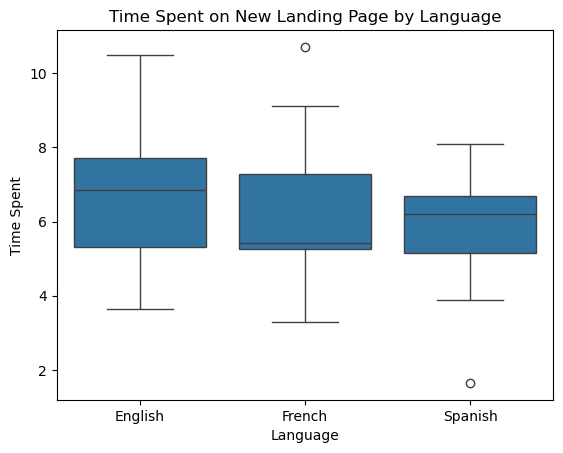

In [35]:
#Visualized in boxplot form
sns.boxplot(x='language_preferred', y='time_spent_on_the_page', data=df[df['landing_page']=='new'], order=['English', 'French', 'Spanish'])
plt.title('Time Spent on New Landing Page by Language')
plt.xlabel('Language')
plt.ylabel('Time Spent')
plt.show()

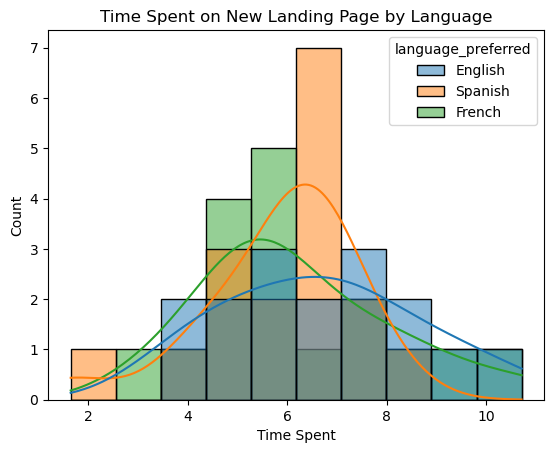

In [36]:
#Visualized in hitogram
sns.histplot(x='time_spent_on_the_page', hue='language_preferred', data=df[df['landing_page']=='new'], kde=True, bins=10)
plt.title('Time Spent on New Landing Page by Language')
plt.xlabel('Time Spent')
plt.ylabel('Count')
plt.show()

**Time Spent on Old Landing Page by Language Preference**

In [37]:
#Time spent on the old landing page by language
df[df['landing_page']=='old'].groupby('language_preferred')['time_spent_on_the_page'].describe()

,count,mean,std,min,25%,50%,75%,max
language_preferred,,,,,,,,
English,16.0,4.454375,2.767287,0.22,2.9325,3.70,6.16,10.30
French,17.0,4.310000,3.022321,0.40,1.8100,4.18,7.40,9.15
Spanish,17.0,4.828235,1.987744,0.19,4.0500,4.75,6.21,8.72


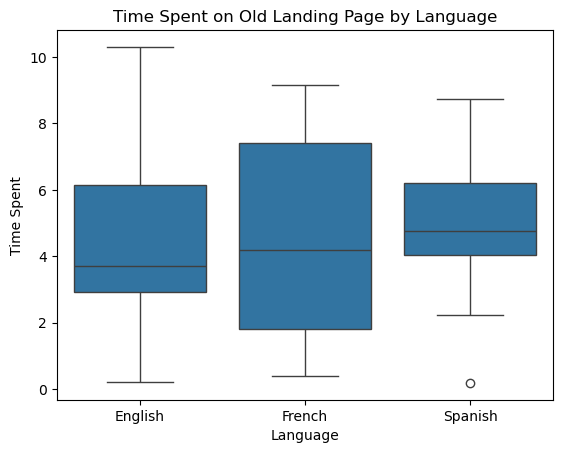

In [38]:
#Visualized in boxplot form
sns.boxplot(x='language_preferred', y='time_spent_on_the_page', data=df[df['landing_page']=='old'], order=['English', 'French', 'Spanish'])
plt.title('Time Spent on Old Landing Page by Language')
plt.xlabel('Language')
plt.ylabel('Time Spent')
plt.show()

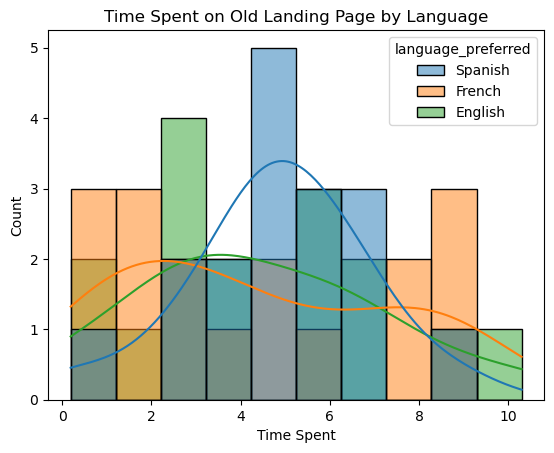

In [39]:
#Visualized in hitogram
sns.histplot(x='time_spent_on_the_page', hue='language_preferred', data=df[df['landing_page']=='old'], kde=True, bins=10)
plt.title('Time Spent on Old Landing Page by Language')
plt.xlabel('Time Spent')
plt.ylabel('Count')
plt.show()

Mean times spent on the landing pages are similar for all 3 languages with Spanish having the smallest standard deviation, and French having the lowest mean time.

There is some notable difference in the mean times spent on the new page.  Whether this difference is statistically significant will be investigated below.

**Language Preference and Conversion Rates**

In [40]:
#Comparing language preference and conversion results
df.groupby('language_preferred')['converted'].value_counts()

language_preferred  converted
English             yes          21
                    no           11
French              no           19
                    yes          15
Spanish             yes          18
                    no           16
Name: count, dtype: int64

In [41]:
df.groupby('language_preferred')['converted'].value_counts(normalize=True)

language_preferred  converted
English             yes          0.656250
                    no           0.343750
French              no           0.558824
                    yes          0.441176
Spanish             yes          0.529412
                    no           0.470588
Name: proportion, dtype: float64

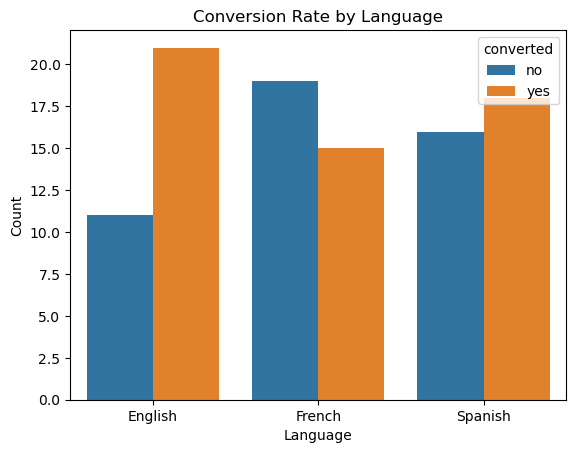

In [42]:
#Visualizing language preference and conversion results
sns.countplot(data=df, x='language_preferred', hue='converted', order=['English', 'French', 'Spanish'])
plt.title('Conversion Rate by Language')
plt.xlabel('Language')
plt.ylabel('Count')
plt.show()

Conversion was highest among English Speakers at 65.6%.

52.9% of Spanish speakers and 44.1% of French Speakers converted.

Whether this is statistically significant enough to indicate differences in user experience or content effectiveness across languages will be investigated below.

## 1. Do the users spend more time on the new landing page than the existing landing page?

### Perform Visual Analysis

Revisiting some of the above visualizations

In [43]:

#Compare summary of time spent on new vs. old landing page
df.groupby('landing_page')['time_spent_on_the_page'].describe()

,count,mean,std,min,25%,50%,75%,max
landing_page,,,,,,,,
new,50.0,6.2232,1.817031,1.65,5.175,6.105,7.1600,10.71
old,50.0,4.5324,2.581975,0.19,2.720,4.380,6.4425,10.30


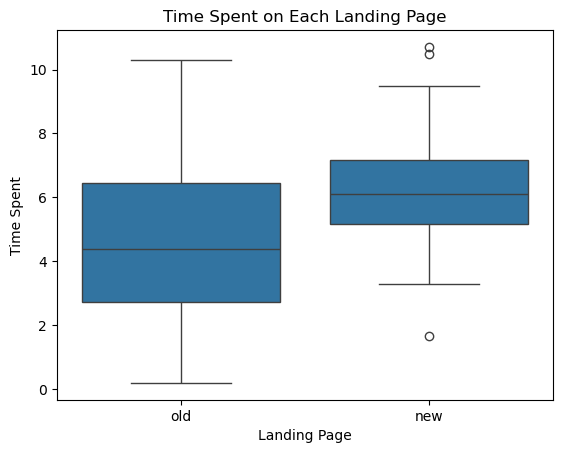

In [44]:
#Visualize in Boxplot form
sns.boxplot(x='landing_page', y='time_spent_on_the_page', data=df)
plt.title('Time Spent on Each Landing Page')
plt.xlabel('Landing Page')
plt.ylabel('Time Spent')
plt.show()

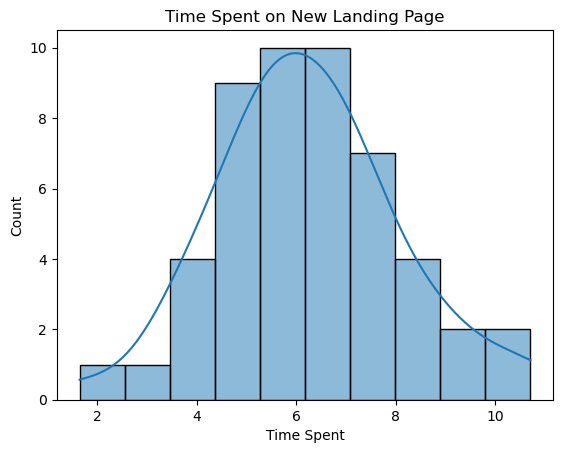

In [45]:
#Visualize in histplot form New Page
sns.histplot(x='time_spent_on_the_page', data=df[df['landing_page']=='new'], kde=True, bins=10)
plt.title('Time Spent on New Landing Page')
plt.xlabel('Time Spent')
plt.ylabel('Count')
plt.show()

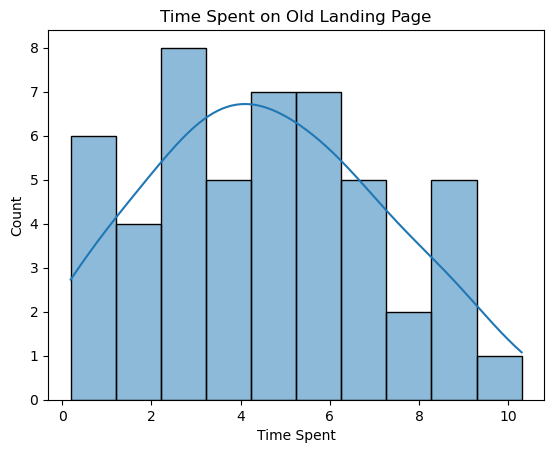

In [46]:
#Visualize in histplot form Old Page
sns.histplot(x='time_spent_on_the_page', data=df[df['landing_page']=='old'], kde=True, bins=10)
plt.title('Time Spent on Old Landing Page')
plt.xlabel('Time Spent')
plt.ylabel('Count')
plt.show()

The data show that the mean and median times spent on the new landing page are higher than those of the old landing page. This indicates that users tend to spend more time on the new page and can be verified using hypothesis testing.

### Step 1: Define the null and alternate hypotheses

$H_0$: Mean Time Spent on New Page <= Mean Time Spent on Old Page

$H_a$: Mean Time Spent on New Page > Mean Time Spent on Old Page

### Step 2: Select Appropriate test

Since we are comparing the means of two independent groups with unknown population standard deviations, we will use a Two Independent Sample T-test.  We will use a one tail test since we are primarily concerned with if the new page mean is greater than the old page mean.

First let's determine if we can assume equal standard deviations of the populations (equal_var = True or False for our test)

In [47]:
#Levene test to check if population variances can be assumed to be equal
stat, p = stats.levene(df[df['landing_page']=='new']['time_spent_on_the_page'], df[df['landing_page']=='old']['time_spent_on_the_page'])
print(f"Levene's Test p-value: {p:.4f}")

if p>0.05:
    print("The population variances can be treated as equal.")
else:
    print("The population variances are not equal.")

Levene's Test p-value: 0.0090
The population variances are not equal.


Levene's test resulted in a p-value less than the significance level of 0.05, so we will reject the null hypothesis of equal variances for the Levene Test.

### Step 3: Decide the significance level

α = 0.05

### Step 4: Collect and prepare data

In [48]:
#Separating samples into time spent on new page and time spent on old page.
new_page_time = df[df['landing_page']=='new']['time_spent_on_the_page']
old_page_time = df[df['landing_page']=='old']['time_spent_on_the_page']

### Step 5: Calculate the p-value

In [49]:
#Calculating P-Value for two sample independent T-test with unequal std
t_stat, p_value = stats.ttest_ind(new_page_time, old_page_time, equal_var=False, alternative='greater')
print(f"P-value: {p_value:.6f}")

P-value: 0.000139


### Step 6: Compare the p-value with $\alpha$

In [50]:
#Compare p-value with significance level and determin if we reject the null hypothesis or not
if p_value < 0.05:
  print("Reject the null hypothesis. There is sufficient evidence at a 5% significance level to conclude that: Mean Time Spent on New Page > Mean Time Spent on Old Page")
else:
  print("Fail to reject the null hypothesis. There is not sufficient evidence at a 5% significance level to conclude that Mean Time Spent on New Page > Mean Time Spent on Old Page.")

Reject the null hypothesis. There is sufficient evidence at a 5% significance level to conclude that: Mean Time Spent on New Page > Mean Time Spent on Old Page


### Step 7:  Draw inference

Since the P-Value is less than the selected level of significance, we reject the null hypothesis and conclude that Mean Time Spent on New Page > Mean Time Spent on Old Page.

*Actionable Insight*: Conduct further research into elements of new page that are driving more engagement and further leverage those elements in future iterations.

**A similar approach can be followed to answer the other questions.**

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

### Visual Analysis

In [51]:
#New vs. old page conversions
df.groupby('landing_page')['converted'].value_counts()

landing_page  converted
new           yes          33
              no           17
old           no           29
              yes          21
Name: count, dtype: int64

In [52]:
#Normalized new vs. old page conversions
df.groupby('landing_page')['converted'].value_counts(normalize=True)

landing_page  converted
new           yes          0.66
              no           0.34
old           no           0.58
              yes          0.42
Name: proportion, dtype: float64

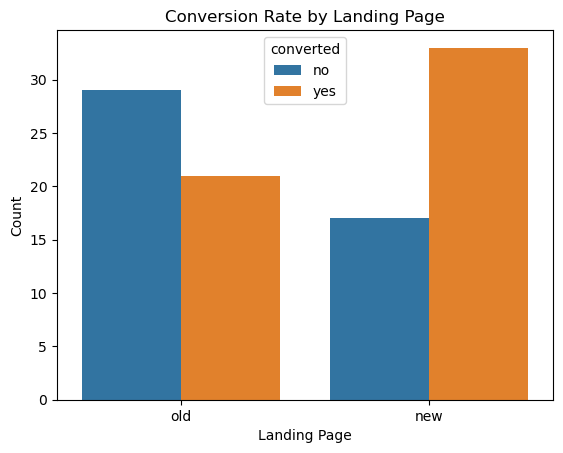

In [53]:
#Visualize with Count Plot
sns.countplot(x='landing_page', hue='converted', data=df)
plt.title('Conversion Rate by Landing Page')
plt.xlabel('Landing Page')
plt.ylabel('Count')
plt.show()

The conversion rate of the new page (66%) is substantially higher than the old page (42%) indicating significant improvement that should be validated through hypothesis testing.

### Null and alternate hypotheses

$H_0$: Conversion Rate of New Page <= Conversion Rate of Old Page

$H_a$: Conversion Rate of New Page > Conversion Rate of Old Page

### Test Selection

Since we have two count proportions from two independent samples, we will use the Two Proportion Z-Test.

### Significance Level

α = 0.05

### Prepare Data

In [54]:
#Find number of observations made for each page
nobs_new = df[df['landing_page']=='new'].shape[0]
nobs_old = df[df['landing_page']=='old'].shape[0]

#Find number of people converted for each page
converted_new = df[(df['landing_page']=='new') & (df['converted']=='yes')].shape[0]
converted_old = df[(df['landing_page']=='old') & (df['converted']=='yes')].shape[0]

print('Number of Observations for New Page:', nobs_new)
print('Number of Observations for Old Page:', nobs_old)
print('Count of Converted Observations for New Page:', converted_new)
print('Count of Converted Observations for Old Page:', converted_old)

Number of Observations for New Page: 50
Number of Observations for Old Page: 50
Count of Converted Observations for New Page: 33
Count of Converted Observations for Old Page: 21


### P-Value and Comparison

In [55]:
#Import the required test
from statsmodels.stats.proportion import proportions_ztest

#Run two proportion z-test and print p-value
test_stat, p_value = proportions_ztest([converted_new, converted_old], [nobs_new, nobs_old], alternative='larger')
print(f"P-value: {p_value:.4f}")

#Compare p-value with significance level and determine whether to reject the null hypothesis or not
if p_value < 0.05:
  print("Reject the null hypothesis. There is sufficient evidence at a 5% significance level to conclude that: Conversion Rate of New Page > Conversion Rate of Old Page")
else:
  print("Fail to reject the null hypothesis. There is not sufficient evidence at a 5% significance level to conclude that: Conversion Rate of New Page > Conversion Rate of Old Page.")

P-value: 0.0080
Reject the null hypothesis. There is sufficient evidence at a 5% significance level to conclude that: Conversion Rate of New Page > Conversion Rate of Old Page


### Inference

Since the P-Value is less than the selected level of significance, we reject the null hypothesis and conclude that Conversion Rate of New Page > Conversion Rate of Old Page.

*Actionable Insight*: Implement New Landing Page as default.

## 3. Are the conversion and preferred language independent or related?

### Visual Analysis

In [56]:
#Comparing language preference and conversion results
df.groupby('language_preferred')['converted'].value_counts()

language_preferred  converted
English             yes          21
                    no           11
French              no           19
                    yes          15
Spanish             yes          18
                    no           16
Name: count, dtype: int64

In [57]:
df.groupby('language_preferred')['converted'].value_counts(normalize=True)

language_preferred  converted
English             yes          0.656250
                    no           0.343750
French              no           0.558824
                    yes          0.441176
Spanish             yes          0.529412
                    no           0.470588
Name: proportion, dtype: float64

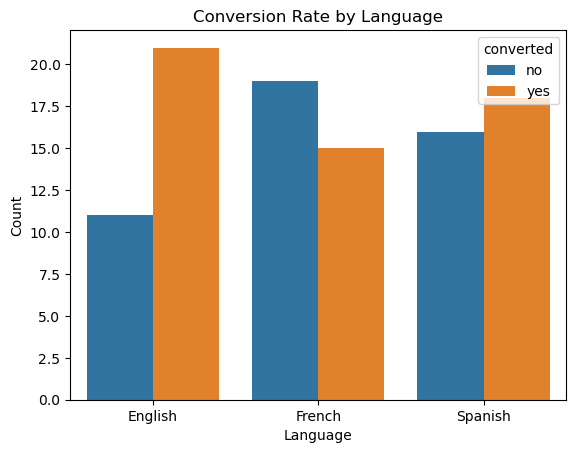

In [58]:
#Visualizing language preference and conversion results
sns.countplot(data=df, x='language_preferred', hue='converted', order=['English', 'French', 'Spanish'])
plt.title('Conversion Rate by Language')
plt.xlabel('Language')
plt.ylabel('Count')
plt.show()

Conversion was highest among English Speakers at 65.6%.

52.9% of Spanish speakers and 44.1% of French Speakers converted.

This may indicate differences in user experience or content effectiveness across languages warranting further investigation.

### Null and alternate hypotheses

$H_0$: Language and Conversion are independent

$H_a$: Language and Conversion are not independent

### Test Selection

Since we are testing the independence of 2 categorical variables we will use the Chi-Square Test for independence.

### Significance Level

α = 0.05

### Prepare Data

In [59]:
#Create Contingency Table of language vs Conversion counts for Chi-Square Test
language_conversion = pd.crosstab(df['language_preferred'], df['converted'])
language_conversion

converted,no,yes
language_preferred,,
English,11,21
French,19,15
Spanish,16,18


### P-Value and Comparison

In [60]:
#Run Chi Square Test for Independence
chi, p_value, dof, expected = stats.chi2_contingency(language_conversion)
print('Expected Frequencies\n', expected)


#Check Test Validity with expected frequencies
if (expected >= 5).all():
    print("Test is valid: All expected frequencies are >= 5.")
else:
    print("Test may not be valid: Some expected frequencies are < 5.")

#Compare P-Value with Level of Significance to determine if we can reject Null Hypothesis of Independence
print(f"\nP-value: {p_value:.4f}")
if p_value < 0.05:
  print('Reject the null hypothesis. There is sufficient evidence at a 5% significance level to conclude that: Language and Conversion are not independent.')
else:
  print('Fail to reject null hypothesis.  There is not sufficient evidence at a 5% significance level to reject the Null hypothesis that Language and Conversion are independent.')

Expected Frequencies
 [[14.72 17.28]
 [15.64 18.36]
 [15.64 18.36]]
Test is valid: All expected frequencies are >= 5.

P-value: 0.2130
Fail to reject null hypothesis.  There is not sufficient evidence at a 5% significance level to reject the Null hypothesis that Language and Conversion are independent.


### Inference

Since the P-Value is greater than the selected level of significance, we fail to reject the null hypothesis.  There is insufficient evidence at a 5% significance level to conclude that language preference and conversion status are associated. Although the observed conversion rates differ across language groups, the Chi-square test indicates that these differences are not statistically significant and are likely due to random variation.

*Actionable Insight*: Maintain consistent experience across languages in future development.

*Actionable Insight*: Monitor language performance with larger samples.

## 4. Is the time spent on the new page the same for the different language users?

### Visual Analysis

In [61]:
#Time spent on the new landing page by language
df[df['landing_page']=='new'].groupby('language_preferred')['time_spent_on_the_page'].describe()

,count,mean,std,min,25%,50%,75%,max
language_preferred,,,,,,,,
English,16.0,6.663750,1.984150,3.65,5.3275,6.865,7.7125,10.50
French,17.0,6.196471,1.933394,3.30,5.2500,5.420,7.2700,10.71
Spanish,17.0,5.835294,1.525656,1.65,5.1500,6.200,6.7000,8.08


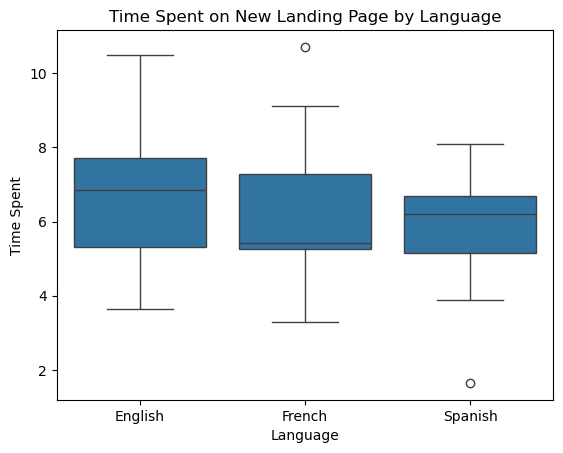

In [62]:
#Visualized in boxplot form
sns.boxplot(x='language_preferred', y='time_spent_on_the_page', data=df[df['landing_page']=='new'], order=['English', 'French', 'Spanish'])
plt.title('Time Spent on New Landing Page by Language')
plt.xlabel('Language')
plt.ylabel('Time Spent')
plt.show()

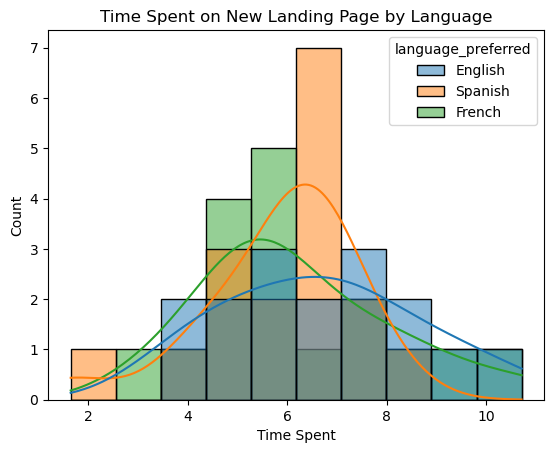

In [63]:
#Visualized in hitogram
sns.histplot(x='time_spent_on_the_page', hue='language_preferred', data=df[df['landing_page']=='new'], kde=True, bins=10)
plt.title('Time Spent on New Landing Page by Language')
plt.xlabel('Time Spent')
plt.ylabel('Count')
plt.show()

From the sample, mean time spent on the new landing page is highest from English speakers (6.7 min.) with Spanish (6.2 min.) and French (5.8 min.) coming in a little lower.  We can run a hypothesis test to see if these results are statistically significant.

### Null and alternate hypotheses

$H_0$: Mean time English = Mean time Spanish = Meantime French

$H_a$: Mean times spent on the new page are not all =

### Test Selection

Since we are concerned with comparing 3 means in one category, we will use the One-Way ANOVA for variance.

### Significance Level

α = 0.05

### Prepare Data

In [64]:
#Select data sets for mean comparison
english_time = df[(df['landing_page']=='new') & (df['language_preferred']=='English')]['time_spent_on_the_page']
spanish_time = df[(df['landing_page']=='new') & (df['language_preferred']=='Spanish')]['time_spent_on_the_page']
french_time = df[(df['landing_page']=='new') & (df['language_preferred']=='French')]['time_spent_on_the_page']

In [65]:
#Verify Assumptions

#Validate Common Variance Assumption with Levene Test
stat, p = stats.levene(english_time, spanish_time, french_time)
print(f"Levene's Test p-value: {p:.4f}")
if p>0.05:
    print("The population variances can be treated as equal.")
else:
    print("The population variances are not equal.")

#Validaate Normal Distribution Assumption with Shapiro-Wilk Test
stat, p_english = stats.shapiro(english_time)
print(f"\nShapiro-Wilk Test English p-value: {p_english:.4f}")
if p_english>0.05:
    print("The English data is normally distributed.")
else:
    print("The English data is not normally distributed.")

stat, p_spanish = stats.shapiro(spanish_time)
print(f"\nShapiro-Wilk Test Spanish p-value: {p_spanish:.4f}")
if p_spanish>0.05:
    print("The Spanish data is normally distributed.")
else:
    print("The Spanish data is not normally distributed.")

stat, p_french = stats.shapiro(french_time)
print(f"\nShapiro-Wilk Test French p-value: {p_french:.4f}")
if p_french>0.05:
    print("The French data is normally distributed.")
else:
    print("The French data is not normally distributed.")

Levene's Test p-value: 0.4671
The population variances can be treated as equal.

Shapiro-Wilk Test English p-value: 0.8863
The English data is normally distributed.

Shapiro-Wilk Test Spanish p-value: 0.0901
The Spanish data is normally distributed.

Shapiro-Wilk Test French p-value: 0.3214
The French data is normally distributed.


### P-Value and Comparison

In [66]:
test_stat, p_value = stats.f_oneway(english_time, spanish_time, french_time)
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
  print('Reject the null hypothesis. There is sufficient evidence at a 5% significance level to conclude that at least two of the mean times are not equal.')
else:
  print('Fail to reject the null hypothesis.  There is not sufficient evidence at a 5% significance level to conclude that at least one group mean is different.')

P-value: 0.4320
Fail to reject the null hypothesis.  There is not sufficient evidence at a 5% significance level to conclude that at least one group mean is different.


### Inference

Since the P-Value is greater than the selected level of significance, we fail to reject the null hypothesis.  There is insufficient evidence at a 5% significance level to conclude that mean time spent on the new landing page differs by language preference. Although the observed sample means vary, the ANOVA test indicates that these differences are not statistically significant and are likely due to random variation.

*Actionable Insight*: Maintain consistent experience across languages in future development.

*Actionable Insight*: Monitor language performance with larger samples.

## Conclusion and Business Recommendations

**Executive Summary**

The analysis shows that the new landing page significantly improves both user engagement and conversion rates compared to the old page. Differences in performance across language groups were observed in testing but are not statistically significant, indicating consistent effectiveness across audiences. Based on these findings, *the new landing page should be implemented as the default experience*. Continued A/B testing and optimization of high-performing elements are recommended to further enhance user engagement and drive subscriber growth.

**Observations**

*Time Spent on Landing Page Comparison*

In the test, the mean time spent on the New Page was greater at 6.22 minutes vs. 4.53 minutes on the Old Page.

Using a two-independent-sample t-test, we concluded (at a 5% significance level) that users spend more time on the New Page than on the Old Page.

*Conversion Rate Comparison*

In the test, the conversion rate for the New Page was higher at 66% vs. 44% for the Old Page.

Using a two-proportion z-test, we concluded (at a 5% significance level) that the conversion rate of the New Page is greater than that of the Old Page.

*Language Preference and Conversion Rate*

In the test, conversion was highest among English speakers at 65.6%, compared to 52.9% for Spanish speakers and 44.1% for French speakers.

However, using a Chi-square test for independence, we found insufficient evidence at a 5% significance level to conclude that language preference and conversion status are associated. This indicates that the observed differences are not statistically significant and may be due to random variation.

*Language Preference and Time Spent on New Page*

In the test, the mean time spent on the New Landing Page was highest among English speakers (6.7 minutes), followed by Spanish (6.2 minutes) and French (5.8 minutes).

However, using a one-way ANOVA test, we found insufficient evidence at a 5% significance level to conclude that mean time spent on the New Landing Page differs by language preference. This suggests that the observed differences in sample means are not statistically significant and may be due to random variation.

**Recommended Actions**

*1. Implement the New Landing Page*

The new landing page should be adopted as the default experience, as it leads to significantly higher user engagement and conversion rates. Users spend more time on the page and convert at a higher rate, indicating improved effectiveness in driving subscriptions.


---



*2. Analyze and Leverage High-Performing Page Elements*

Since the new page increases both time spent and conversion, the company should identify which specific elements are driving this improvement. This may include:

*   Page layout and structure
*   Content relevance and personalization
*   Visual design and call-to-action placement

These insights can be used to further optimize the current page and guide future design iterations.


---


*3. Prioritize Engagement as a Key Driver of Conversion*

The analysis suggests that users who spend more time on the page are more likely to convert. Therefore, the company should:

*   Focus on increasing user engagement time
*   Introduce interactive or personalized content
*   Optimize content flow to retain user attention

Improving engagement is likely to have a direct positive impact on conversion rates.


---


*4. Maintain a Consistent Experience Across Languages*

Although there are observed differences in conversion rates across language groups, these differences are not statistically significant. This suggests that the current design performs consistently across languages.

*   No immediate need for language-specific redesigns
*   Continue offering a uniform experience across language options


---


*5. Monitor Language Performance with Larger Samples*

While current results do not show a significant relationship between language and conversion, the observed differences may still be meaningful with a larger dataset.


*   Continue collecting data on language preferences
*   Re-evaluate with a larger sample size
*   Investigate potential cultural or translation improvements if trends persist

___